In [1]:
import pandas as pd
from pathlib import Path

In [ ]:
year = 2021

In [ ]:
df = pd.read_csv(Path(f"../data/processed/data_air_quality_{year}.csv"), sep=";")
df.shape

(1305096, 23)

In [3]:
df.head(5)

,Date de début,Date de fin,Organisme,code zas,Zas,code site,nom site,type d'implantation,Polluant,type d'influence,...,procédure de mesure,type de valeur,valeur,valeur brute,unité de mesure,taux de saisie,couverture temporelle,couverture de données,code qualité,validité
0,2021/01/01 00:00:00,2021/01/01 01:00:00,AIRPARIF,FR11ZAG01,ZAG PARIS,FR04002,GENNEVILLIERS,Urbaine,NO,Fond,...,Auto NO app AC32M,moyenne horaire validée,25.0,25.025,µg-m3,NaN,NaN,NaN,A,1
1,2021/01/01 01:00:00,2021/01/01 02:00:00,AIRPARIF,FR11ZAG01,ZAG PARIS,FR04002,GENNEVILLIERS,Urbaine,NO,Fond,...,Auto NO app AC32M,moyenne horaire validée,26.4,26.375,µg-m3,NaN,NaN,NaN,A,1
2,2021/01/01 02:00:00,2021/01/01 03:00:00,AIRPARIF,FR11ZAG01,ZAG PARIS,FR04002,GENNEVILLIERS,Urbaine,NO,Fond,...,Auto NO app AC32M,moyenne horaire validée,21.8,21.825,µg-m3,NaN,NaN,NaN,A,1
3,2021/01/01 03:00:00,2021/01/01 04:00:00,AIRPARIF,FR11ZAG01,ZAG PARIS,FR04002,GENNEVILLIERS,Urbaine,NO,Fond,...,Auto NO app AC32M,moyenne horaire validée,20.1,20.050,µg-m3,NaN,NaN,NaN,A,1
4,2021/01/01 04:00:00,2021/01/01 05:00:00,AIRPARIF,FR11ZAG01,ZAG PARIS,FR04002,GENNEVILLIERS,Urbaine,NO,Fond,...,Auto NO app AC32M,moyenne horaire validée,23.3,23.300,µg-m3,NaN,NaN,NaN,A,1


In [4]:
df_no2 = df[df['Polluant'] == "NO2"]
df_o3 = df[df['Polluant'] == "O3"]
df_pm10 = df[df['Polluant'] == "PM10"]
print("NO2 df shape:", df_no2.shape, "\nO3 df shape:", df_o3.shape, "\nPM10 df shape:", df_pm10.shape)

NO2 df shape: (307224, 23) 
O3 df shape: (131232, 23) 
PM10 df shape: (157320, 23)


In [5]:
df_no2['Date'] = pd.to_datetime(df_no2['Date de début'])
df_o3['Date'] = pd.to_datetime(df_o3['Date de début'])
df_pm10['Date'] = pd.to_datetime(df_pm10['Date de début'])

In [6]:
# Count no of time NO2 exceeds 130µg-m3
print("Number of hours NO2 exceeds 130µg-m3:", (df_no2['valeur'] >= 130).sum())
# Count no of time O3 exceeds 130µg-m3
print("Number of hours O3 exceeds 130µg-m3:", (df_o3['valeur'] >= 130).sum())

Number of hours NO2 exceeds 130µg-m3: 83
Number of hours O3 exceeds 130µg-m3: 167


In [7]:
# Number of days where max NO2 of the day exceeds 130
print("Number of days NO2 daily max exceeds 130µg-m3:", (df_no2.groupby('Date')['valeur'].max() >= 130).sum())
(df_no2.groupby('Date')['valeur'].max()).reset_index()[lambda x: x['valeur'] >= 130]
# Number of days where max O3 of the day exceeds 130
print("Number of days O3 daily max exceeds 130µg-m3:", (df_o3.groupby('Date')['valeur'].max() >= 130).sum())
(df_o3.groupby('Date')['valeur'].max()).reset_index()[lambda x: x['valeur'] >= 130]
# PM10 daily mean exceeds 50µg-m3
daily_mean_pm10 = df_pm10.groupby('Date')['valeur'].mean()
print("Number of days PM10 daily mean exceeds 50µg-m3:", (daily_mean_pm10 >= 50).sum())

Number of days NO2 daily max exceeds 130µg-m3: 62
Number of days O3 daily max exceeds 130µg-m3: 60
Number of days PM10 daily mean exceeds 50µg-m3: 248


In [8]:
# Number of sites where daily max concentration of O3 exceeds 130µg-m3
o3_max_per_station = df_o3.groupby(['Date', 'nom site'])['valeur'].max().reset_index()
o3_exceedance = o3_max_per_station[o3_max_per_station['valeur'] >= 130]

print(f"Number of events (station-day) O3 exceeds 130µg-m3: {len(o3_exceedance)}")
print(o3_exceedance)

# Number of sites where daily mean concentration of PM10 exceeds 50µg-m3
pm10_mean_per_station = df_pm10.groupby(['Date', 'nom site'])['valeur'].mean().reset_index()
pm10_exceedance = pm10_mean_per_station[pm10_mean_per_station['valeur'] >= 50]

print(f"Number of events (station-day) PM10 exceeds 50µg-m3: {len(pm10_exceedance)}")
print(pm10_exceedance)

Number of events (station-day) O3 exceeds 130µg-m3: 167
                     Date           nom site  valeur
54507 2021-06-01 13:00:00     CERGY-PONTOISE   132.6
54522 2021-06-01 14:00:00     CERGY-PONTOISE   134.4
54526 2021-06-01 14:00:00    MANTES-LA-JOLIE   136.2
54537 2021-06-01 15:00:00     CERGY-PONTOISE   135.7
54539 2021-06-01 15:00:00           LES ULIS   130.1
...                   ...                ...     ...
90097 2021-09-08 14:00:00  NEUILLY-SUR-SEINE   132.7
90098 2021-09-08 14:00:00        PARIS 13eme   132.3
90104 2021-09-08 14:00:00    VITRY-SUR-SEINE   132.0
90105 2021-09-08 15:00:00     CERGY-PONTOISE   150.6
90114 2021-09-08 15:00:00        PARIS 18eme   134.8

[167 rows x 3 columns]
Number of events (station-day) PM10 exceeds 50µg-m3: 5751
                      Date              nom site  valeur
0      2021-01-01 00:00:00  Auto A1 -Saint-Denis    58.7
6      2021-01-01 00:00:00         GENNEVILLIERS    52.7
10     2021-01-01 00:00:00           PARIS 18eme    50.

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

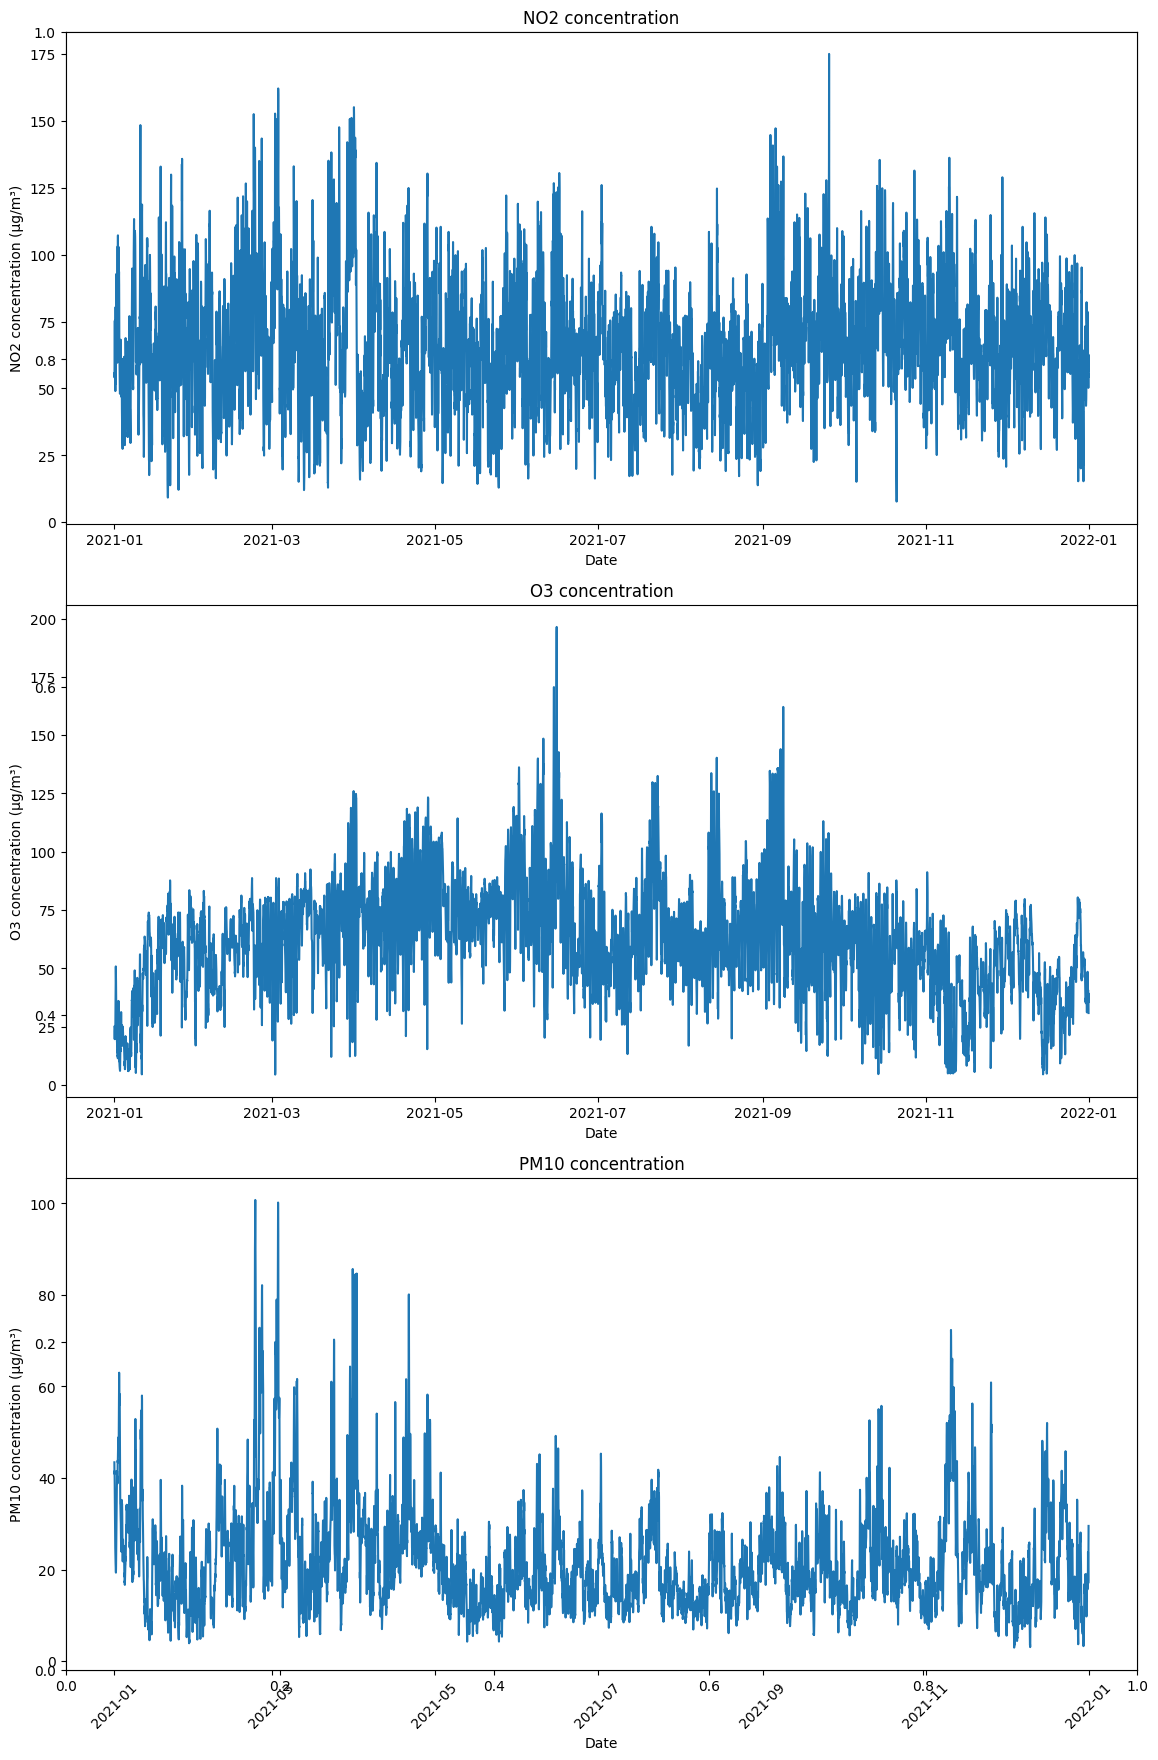

In [10]:
plt.subplots(figsize=(12, 18))
# Daily evolution of NO2
plt.subplot(3, 1, 1)
daily_no2 = df_no2.groupby('Date')['valeur'].max().reset_index()
sns.lineplot(x='Date', y='valeur', data=daily_no2)
plt.title("NO2 concentration")
plt.xlabel("Date")
plt.ylabel("NO2 concentration (µg/m³)")
# Daily evolution of O3
plt.subplot(3, 1, 2)
daily_o3 = df_o3.groupby('Date')['valeur'].max().reset_index()
sns.lineplot(x='Date', y='valeur', data=daily_o3)
plt.title("O3 concentration")
plt.xlabel("Date")
plt.ylabel("O3 concentration (µg/m³)")
# Daily evolution of PM10
plt.subplot(3, 1, 3)
daily_pm10 = df_pm10.groupby('Date')['valeur'].mean().reset_index()
sns.lineplot(x='Date', y='valeur', data=daily_pm10)
plt.title("PM10 concentration")
plt.xlabel("Date")
plt.ylabel("PM10 concentration (µg/m³)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()